# Modelagem de Churn - Random Forest
## PRT Seguros

Modelo robusto ensemble com 300 árvores de decisão para previsão de churn de clientes.

## 1. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Paleta PRT
PRT_NAVY = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY = "#737C8A"
RANDOM_STATE = 42

## 2. CARREGAR E PREPARAR DADOS

In [2]:
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Outer.csv")
print(f"Shape inicial: {df.shape}")
df.head()

Shape inicial: (100000, 84)


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,...,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,churned,num_apolices_premium,num_apolices_basica,num_apolices_padrao
0,221300000040,2.0,1077.82,2165.0,27/06/2020,2.0,161891.00,1083.49,1.0,0.049,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,0.0,2.0
1,221300000051,1.0,1342.00,4309.0,14/08/2014,4.0,131680.75,753.93,1.0,0.054,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,0.0,1.0
2,221300000085,3.0,1542.00,1550.0,04/03/2022,1.0,81434.11,1732.02,1.0,0.081,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,3.0,0.0
3,221300000119,2.0,1189.46,1651.0,23/11/2021,NaN,121370.92,657.88,1.0,0.033,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,2.0
4,221300000218,NaN,620.10,1902.0,17/03/2021,2.0,153965.39,662.30,1.0,0.035,...,0.0,0.0,1.0,0.0,0.0,0.0,0,NaN,NaN,NaN


## 3. REMOVER COLUNAS DE LEAKAGE E DATA

In [3]:
# Remover vazamento
colunas_vazamento = ["score_propensao_churn", "cluster_sugerido_crm"]
presentes = [c for c in colunas_vazamento if c in df.columns]
if presentes:
    print(f"Removendo colunas de vazamento: {presentes}")
    df = df.drop(columns=presentes)

# Remover colunas de data (causam explosão de features)
colunas_data = ["data_primeira_apolice", "data_nascimento"]
presentes_data = [c for c in colunas_data if c in df.columns]
if presentes_data:
    print(f"Removendo colunas de data: {presentes_data}")
    df = df.drop(columns=presentes_data)

# Remover multicolinearidade
if "renovacoes_consecutivas" in df.columns:
    print(f"Correlação tempo_cliente_dias vs renovacoes_consecutivas: {df[['tempo_cliente_dias', 'renovacoes_consecutivas']].corr().iloc[0, 1]:.3f}")
    df = df.drop(columns=["renovacoes_consecutivas"])

print(f"Shape após limpeza: {df.shape}")

Removendo colunas de vazamento: ['score_propensao_churn', 'cluster_sugerido_crm']
Removendo colunas de data: ['data_primeira_apolice', 'data_nascimento']
Correlação tempo_cliente_dias vs renovacoes_consecutivas: 0.942
Shape após limpeza: (100000, 79)


## 4. DEFINIR TARGET E FEATURES

In [4]:
TARGET = "churned"
y = df[TARGET]
X = df.drop(columns=[TARGET])

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categóricas: {len(cat_cols)} | Numéricas: {len(num_cols)}")

Categóricas: 0 | Numéricas: 78


## 5. ENCODING E TRATAMENTO DE NULOS

In [5]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Shape após encoding: {X_encoded.shape}")

imputer = SimpleImputer(strategy="median")
X_model = X_encoded.copy()
X_model[:] = imputer.fit_transform(X_model)

assert X_model.isnull().sum().sum() == 0, "Ainda há valores nulos"
print("✓ Sem valores nulos")

Shape após encoding: (100000, 78)
✓ Sem valores nulos


## 6. TRAIN/TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras ({y_train.mean():.1%} churn)")
print(f"Teste:  {X_test.shape[0]} amostras ({y_test.mean():.1%} churn)")

Treino: 80000 amostras (12.1% churn)
Teste:  20000 amostras (12.1% churn)


## 7. TREINAR RANDOM FOREST

In [7]:
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Treinando Random Forest (300 árvores)...")
rf.fit(X_train, y_train)
print("✓ Modelo treinado")

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("RANDOM FOREST - RESULTADOS")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["Não-churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Treinando Random Forest (300 árvores)...
✓ Modelo treinado

RANDOM FOREST - RESULTADOS
              precision    recall  f1-score   support

   Não-churn       0.96      0.71      0.81     17581
       Churn       0.27      0.78      0.40      2419

    accuracy                           0.72     20000
   macro avg       0.61      0.74      0.61     20000
weighted avg       0.87      0.72      0.76     20000

ROC-AUC: 0.8176


## 8. MATRIZ DE CONFUSÃO

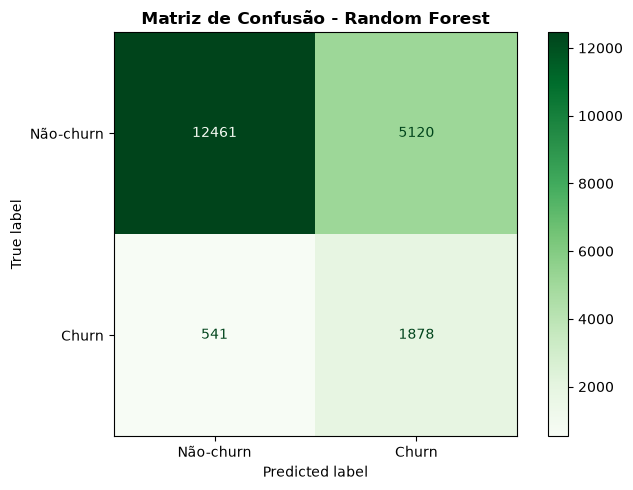

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Não-churn", "Churn"]).plot(
    ax=ax, cmap="Greens", colorbar=True
)
ax.set_title("Matriz de Confusão - Random Forest", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. CURVA ROC

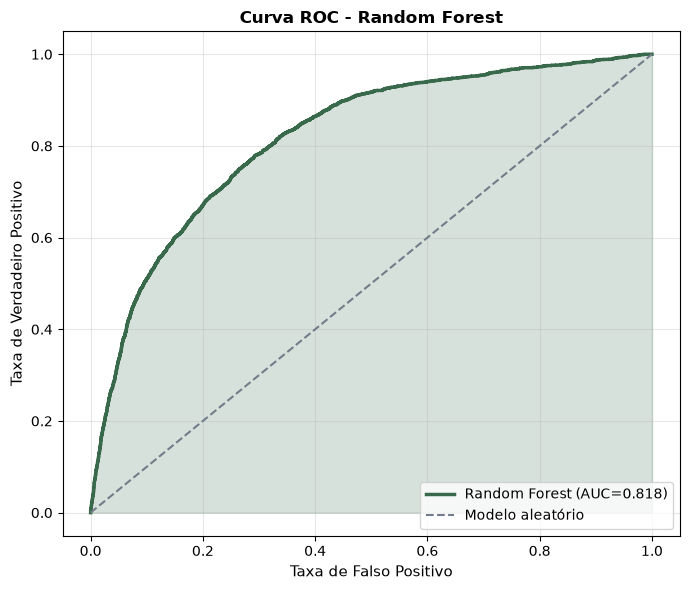

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Random Forest (AUC={auc:.3f})",
        color=PRT_GREEN, linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle="--", color=PRT_GRAY, label="Modelo aleatório")
ax.fill_between(fpr, tpr, alpha=0.2, color=PRT_GREEN)

ax.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax.set_title("Curva ROC - Random Forest", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. CURVA PRECISION-RECALL

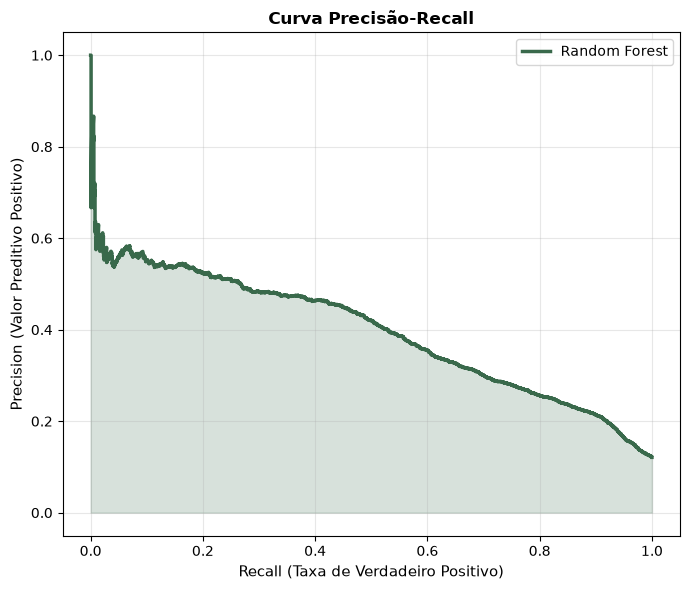

In [10]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, label="Random Forest",
        color=PRT_GREEN, linewidth=2.5)
ax.fill_between(recall, precision, alpha=0.2, color=PRT_GREEN)

ax.set_xlabel("Recall (Taxa de Verdadeiro Positivo)", fontsize=11)
ax.set_ylabel("Precision (Valor Preditivo Positivo)", fontsize=11)
ax.set_title("Curva Precisão-Recall", fontsize=12, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. FEATURE IMPORTANCE

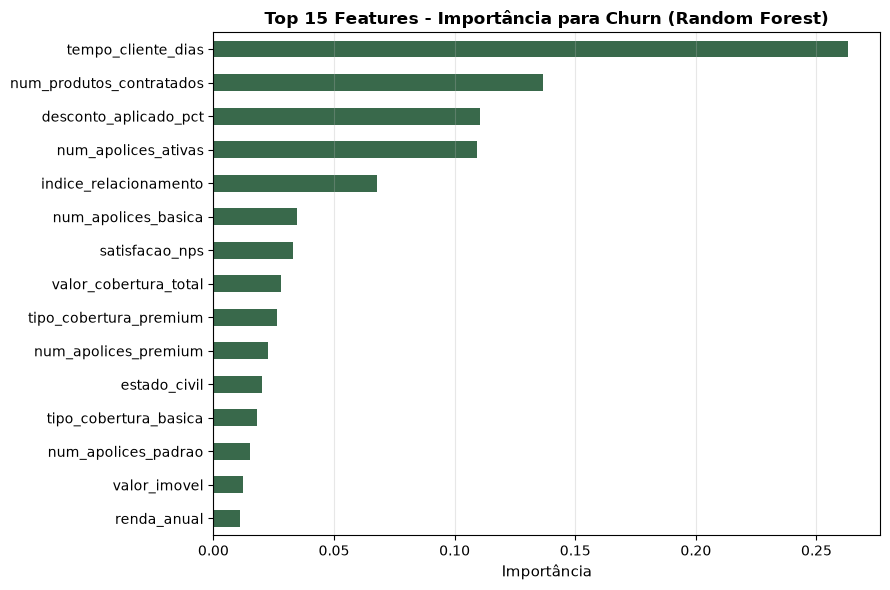


=== TOP 15 FEATURES ===
tempo_cliente_dias          0.263168
num_produtos_contratados    0.136431
desconto_aplicado_pct       0.110326
num_apolices_ativas         0.109284
indice_relacionamento       0.067673
num_apolices_basica         0.034857
satisfacao_nps              0.032862
valor_cobertura_total       0.028027
tipo_cobertura_premium      0.026411
num_apolices_premium        0.022659
estado_civil                0.020139
tipo_cobertura_basica       0.017889
num_apolices_padrao         0.015042
valor_imovel                0.012112
renda_anual                 0.011088
dtype: float64


In [11]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_features.sort_values().plot(kind="barh", ax=ax, color=PRT_GREEN)
ax.set_title("Top 15 Features - Importância para Churn (Random Forest)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importância", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\n=== TOP 15 FEATURES ===")
print(top_features)

## 12. ANÁLISE DE IMPORTÂNCIA ACUMULADA

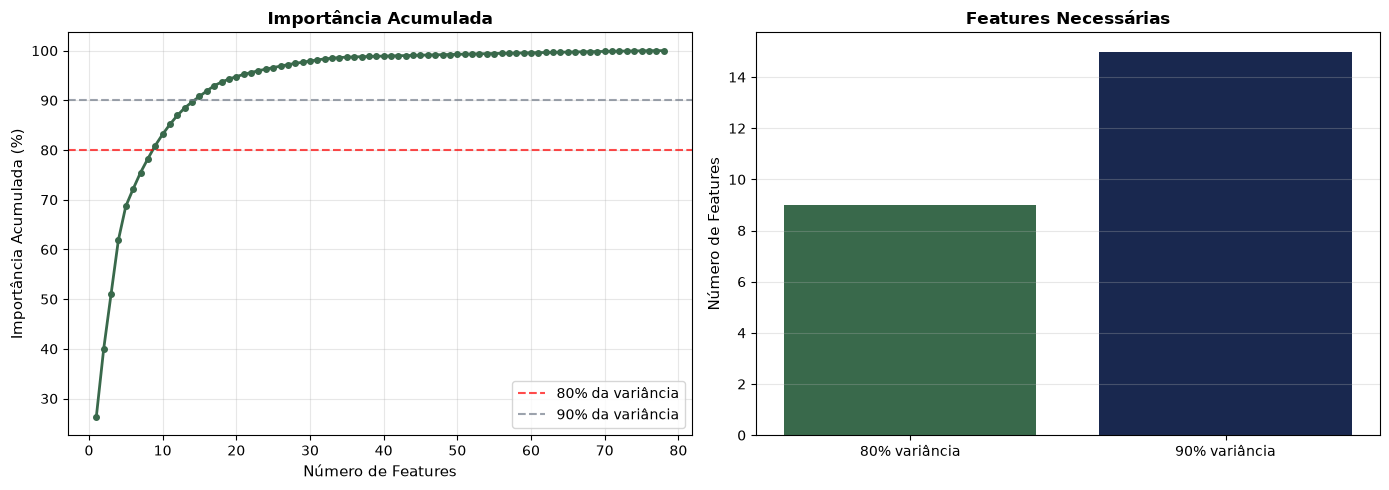


Features necessárias para:
  - 80% da variância: 9 features
  - 90% da variância: 15 features


In [12]:
sorted_importances = importances.sort_values(ascending=False)
cumsum = np.cumsum(sorted_importances.values)
cumsum_pct = (cumsum / cumsum[-1]) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Importância acumulada
ax1.plot(range(1, len(cumsum_pct)+1), cumsum_pct, marker='o', linestyle='-',
         color=PRT_GREEN, linewidth=2, markersize=4)
ax1.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% da variância')
ax1.axhline(y=90, color=PRT_GRAY, linestyle='--', alpha=0.7, label='90% da variância')
ax1.set_xlabel("Número de Features", fontsize=11)
ax1.set_ylabel("Importância Acumulada (%)", fontsize=11)
ax1.set_title("Importância Acumulada", fontsize=12, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Número de features para 80% e 90%
n_features_80 = np.argmax(cumsum_pct >= 80) + 1
n_features_90 = np.argmax(cumsum_pct >= 90) + 1
ax2.bar(["80% variância", "90% variância"], [n_features_80, n_features_90],
        color=[PRT_GREEN, PRT_NAVY])
ax2.set_ylabel("Número de Features", fontsize=11)
ax2.set_title("Features Necessárias", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nFeatures necessárias para:")
print(f"  - 80% da variância: {n_features_80} features")
print(f"  - 90% da variância: {n_features_90} features")